In [1]:
# 必要なモジュールをインポート
import os
from dotenv import load_dotenv
from langchain_openai import ChatOpenAI

# 環境変数の読み込み
load_dotenv("../.env")
os.environ['OPENAI_API_KEY'] = os.environ['API_KEY']

# モデル名
MODEL_NAME = "gpt-4o-mini"

In [2]:
# 検索ツールの定義
from langchain_community.tools.tavily_search import TavilySearchResults

tool = TavilySearchResults(max_results=2)
tools = [tool]

In [3]:
tool.invoke("Langgraphのノードとは？")

[{'url': 'https://www.creationline.com/tech-blog/author/higuchi/75504',
  'content': '## 「ノード」と「エッジ」\n\nまず「グラフ」という概念において、点である「ノード」と線である「エッジ」という構成要素を押さえておく必要がありそうです。LangGraphにおいても、処理を担当する「ノード」と処理同士を接続する「エッジ」という、次のような図になりそうです。\n\n## ２つのノードを接続する\n\n `value` を `1` にする `node1`\n `value` を `2` にする `node2`\n\nと２つのノードがあり、\n\n 処理は `node1` から `node2` に進む\n\nというエッジで２つのノードを接続するとします。また、\n\n `node1` から始まる\n `node2` で終わる\n\nという流れとします。ここで `value` の初期値を `0` として開始するLangGraphスクリプトを書いてみました。'},
 {'url': 'https://note.com/jarinko712/n/n0588f3f96da3',
  'content': '2) 実行\n\n```\n% python3 hello_graph.py こんにちは、HOGEさん！\n```\n\nこのステップでは、LangGraphの最も基本的な仕組みである  \n「状態（State）」「ノード（Node）」「エッジ（Edge）」 の3つを理解し、  \n実際にPythonコードで最小のグラフを構築しました。\n\n### ① State（状態）\n\nグラフ全体で受け渡されるデータを表すもので、  \nここでは「テキスト（text）」だけを持つシンプルな構造体として定義しました。\n\n```\nclass State(TypedDict): text: str \n```\n\nこれにより、LangGraphの各ノード間で  \n「text」というキーを使って値を共有できます。\n\n### ② Node（ノード）\n\nノードは「処理の1ステップ」を表します。  \nこの例では次の2つを定義しました。\n\n greet: 名前に「こんにちは」を付ける\n

In [ ]:
from typing import Annotated
from typing_extensions import TypedDict
from langgraph.graph import StateGraph
from langgraph.graph.message import add_messages

# Stateクラスの定義
class State(TypedDict):
    messages: Annotated[list, add_messages]

# グラフのインスタンスを作成
graph_builder = StateGraph(State)

# 言語モデルの定義
llm = ChatOpenAI(model_name=MODEL_NAME)

# 変更点：ツール定義の紐づけ
llm_with_tools = llm.bind_tools(tools)

# チャットボットノードの作成
def chatbot(state: State):
    return {"messages": [llm_with_tools.invoke(state["messages"])]}

# グラフにチャットボットノードを追加
graph_builder.add_node("chatbot", chatbot)

In [5]:
from langgraph.prebuilt import ToolNode, tools_condition
from langgraph.checkpoint.memory import MemorySaver

# ツールノードの作成
tool_node = ToolNode(tools)

# グラフにツールノードを追加
graph_builder.add_node("tools", tool_node)

# 条件付エッジの作成
graph_builder.add_conditional_edges(
    "chatbot",
    tools_condition, # ツール呼出と判断したらツールノードを呼ぶ
)

# ツールが呼び出されるたびに、チャットボットに戻って次のステップを決定
# ツールからチャットボットへの戻りエッジを作成
graph_builder.add_edge("tools", "chatbot")

# 開始ノードの指定
graph_builder.set_entry_point("chatbot")

# 記憶を持つ実行可能なステートグラフの作成
memory = MemorySaver()
graph = graph_builder.compile(checkpointer=memory)

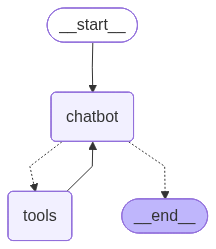

In [6]:
# グラフの可視化
from IPython.display import Image, display

display(Image(graph.get_graph().draw_mermaid_png()))

In [7]:
# グラフの実行と結果の表示
def stream_graph_updates(user_input: str):
    events = graph.stream(
        {"messages": [("user", user_input)]},
        {"configurable": {"thread_id": "1"}},
        stream_mode="values")
    # 結果をストリーミングで得る
    for event in events:
        print(event["messages"][-1].content, flush=True)

# チャットボットのループ
while True:
    user_input = input("質問:")
    if user_input.strip()=="":
        print("ありがとうございました!")
        break
    stream_graph_updates(user_input)

こんにちは！
こんにちは！今日はどのようなことをお手伝いできますか？
1足す2は？
1足す2は3です。何か他にお手伝いできることはありますか？
1メートル以上の魚は？

[{"url": "https://gendai.media/articles/-/80493", "content": "検索\n\nブルーバックス\n\nナビゲーションメニュー\n\n連載よみもの\n\n記事一覧\n\nRikejo\nBluebacks Outreach\nBluebacks Outreach\n\n船上に引き上げられた新種の巨大深海魚「ヨコヅナイワシ」（JAMSTEC提供）\n\n# 「悪魔のサメ」をしのぐ覇者！「新種」の巨大深海魚が見つかった！\n\n１m超の巨体が未発見だったのはなぜ？\n\n山本 智之\n\n科学ジャーナリスト\n\nfacebook シェア\nX ポスト\nline シェア\n\n静岡県沖の駿河湾で、全長が1mを超す新種の深海魚が見つかった。海洋研究開発機構（JAMSTEC）などの研究チームが、今年1月に論文を発表した。\n\n新種の魚は、その巨体から「ヨコヅナイワシ」と名付けられた。小型の魚ならともかく、1m以上の「巨大魚」の存在が今までまったく知られていなかったことに、研究者たちは驚きを隠さない。\n\n突如、我々の前に姿を現したヨコヅナイワシとは、いったい何者なのか？\n\n## 「異様な姿」に船上は騒然\n\n船のデッキに引き上げられたその巨大魚は、青黒く光っていた。体を手でつかもうとすると、大きなウロコがベロッとはがれ落ちた。世界でまだ誰も見たことのない、「未知の巨大魚」との遭遇だった。\n\n「シーラカンスが釣れたのか!?」\n\n異様な姿の魚を目にした船員たちが、驚きの声を上げた。神奈川県立海洋科学高校所属の実習船「湘南丸」の船上は、たちまち騒然とした雰囲気に包まれた。\n\n「シーラカンス」という言葉を聞いて、この船に乗っていたJAMSTECの上席研究員・藤原義弘さんは、慌ててデッキに駆けつけた。\n\n近づいてみると、全体に黒っぽい色の魚だが、頭部やウロコはライトブルーだとわかった。すぐに、「これまでに見たどの魚とも、ぜんぜん違う」ことに気づいたという。\n\n## 「駿河湾のヌシ」を釣り上げた！ [...] こうした点も考慮して、研